In [213]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [214]:
train_df = pd.read_csv(r"C:\Users\wirnk\OneDrive\Dokumente\trained_titanic.csv")
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [215]:
train_df.shape


(891, 12)

In [216]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [217]:
data_dictionary = {
    'PassengerId': 'Unique number for each passenger',
    'Survived': '0 = Died, 1 = Survived',
    'Pclass': 'Ticket class: 1= Upper class, 2= Middle class, 3 = Lower class',
    'Name': "Passenger's full name",
    'Sex': "Gender: male or female",
    'Age': "Age in years",
    'SibSp': "Number of siblings/Spouses on board",
    'Ticket': "Ticket number",
    'Fare': "Ticket price paid",
    'Cabin': "Cabin number",
    'Embarked': "Port where passenger boarded: C=Cherbourg, Q=Queenstown, S=Southampton"
}
print("\n DATA DICTIONARY (Understanding each column):")
for column, description in data_dictionary.items():
    print(f".{column}: {description}")



 DATA DICTIONARY (Understanding each column):
.PassengerId: Unique number for each passenger
.Survived: 0 = Died, 1 = Survived
.Pclass: Ticket class: 1= Upper class, 2= Middle class, 3 = Lower class
.Name: Passenger's full name
.Sex: Gender: male or female
.Age: Age in years
.SibSp: Number of siblings/Spouses on board
.Ticket: Ticket number
.Fare: Ticket price paid
.Cabin: Cabin number
.Embarked: Port where passenger boarded: C=Cherbourg, Q=Queenstown, S=Southampton


In [218]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [219]:
train_df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [220]:
train_df.duplicated().sum()

np.int64(0)

In [221]:
train_clean = train_df.copy()

In [222]:
train_clean["Age"] = train_clean["Age"].fillna(train_clean["Age"].median())

In [223]:
train_clean["Embarked"] = train_clean["Embarked"].fillna(train_clean["Embarked"].mode()[0])

In [224]:
train_clean.drop(columns=["Cabin"], inplace=True)

In [225]:
train_clean["Sex"] = train_clean["Sex"].map({'male': 0, 'female': 1})

In [226]:
train_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(6), object(3)
memory usage: 76.7+ KB


In [227]:
train_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S


In [228]:
train_clean.describe()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,0.352413,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,0.477990,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,0.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,1.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200


In [229]:
#Proportion of male and females who survived
train_clean.groupby("Sex")["Survived"].mean()

Sex
0    0.188908
1    0.742038
Name: Survived, dtype: float64

In [230]:
#Survival proportion by passenger class.
train_clean.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [231]:
train_clean.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,-0.042939,0.034212,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,0.543351,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.131900,-0.339898,0.083081,0.018443,-0.549500
Sex,-0.042939,0.543351,-0.131900,1.000000,-0.081163,0.114631,0.245489,0.182333
Age,0.034212,-0.064910,-0.339898,-0.081163,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.057527,-0.035322,0.083081,0.114631,-0.233296,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,0.245489,-0.172482,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.182333,0.096688,0.159651,0.216225,1.000000


In [232]:
train_clean.groupby("Sex")["Survived"].sum()

Sex
0    109
1    233
Name: Survived, dtype: int64

In [233]:
train_clean.groupby("Pclass")["Survived"].sum()

Pclass
1    136
2     87
3    119
Name: Survived, dtype: int64

In [234]:
train_clean.groupby("Pclass")["PassengerId"].count()

Pclass
1    216
2    184
3    491
Name: PassengerId, dtype: int64

In [235]:
train_clean.to_csv("Titanic_clean.csv",index=False)

In [236]:
import os
print(os.getcwd())

C:\Users\wirnk


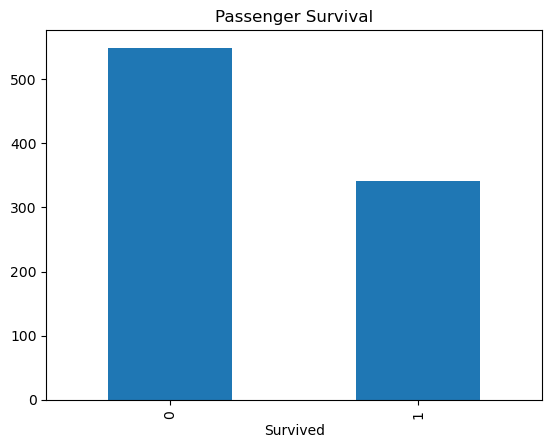

In [237]:
train_clean["Survived"].value_counts().plot(kind='bar')
plt.title("Passenger Survival")
plt.show()

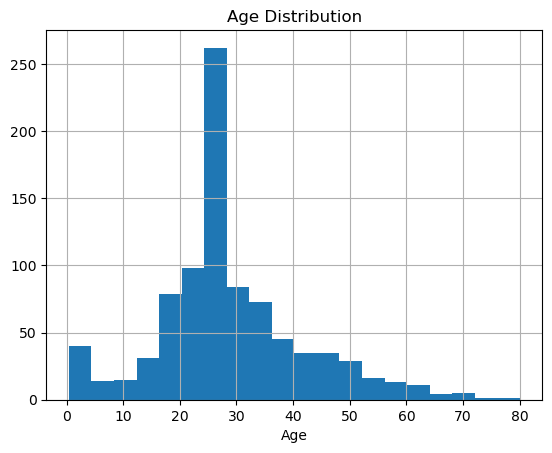

In [238]:
train_clean["Age"].hist(bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

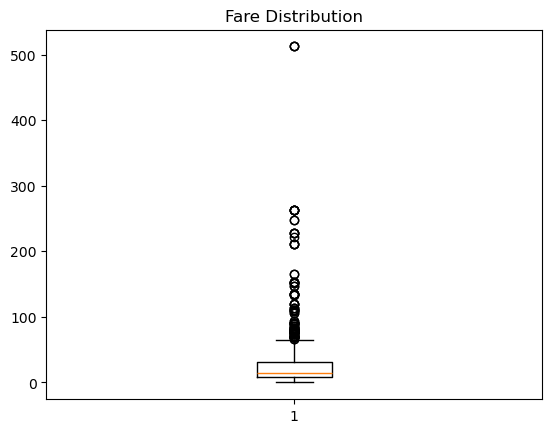

In [239]:
plt.boxplot(train_clean["Fare"])
plt.title("Fare Distribution")
plt.show()

In [240]:
df = train_clean
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,28.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,C


In [241]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(6), object(3)
memory usage: 76.7+ KB


In [242]:
df.describe()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,0.352413,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,0.477990,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,0.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,1.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200


<function matplotlib.pyplot.show(close=None, block=None)>

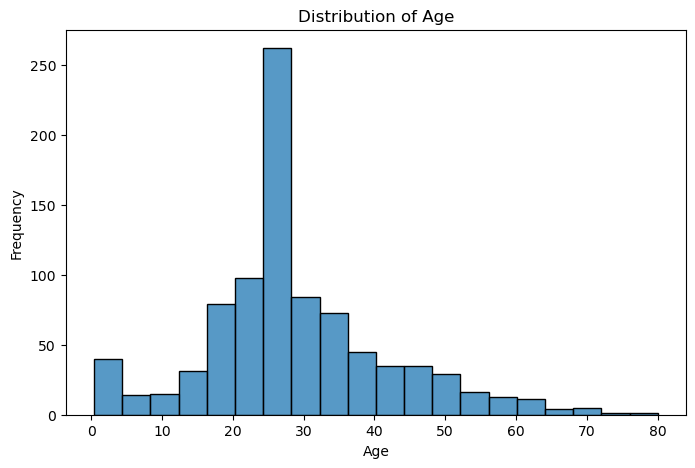

In [243]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show

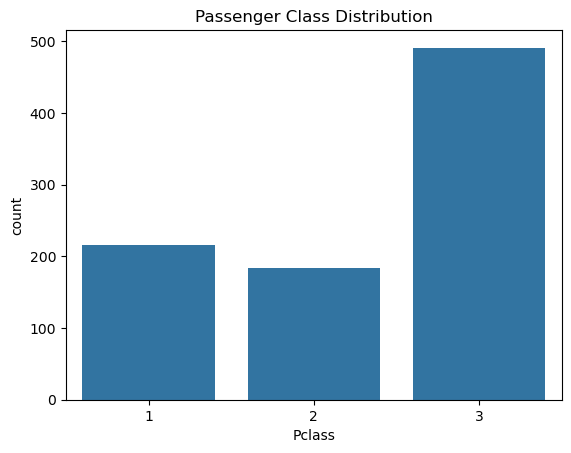

In [244]:
#This shows the number of passengers per class
sns.countplot(x="Pclass", data=df)
plt.title("Passenger Class Distribution")

plt.show()

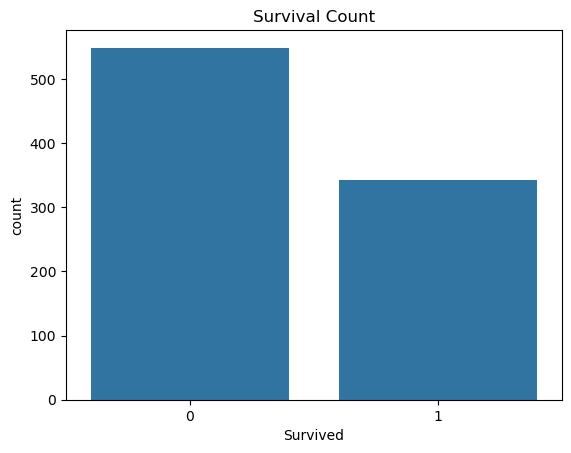

In [245]:
#Showing the number of passengers who died(0) and those who survived(1)
sns.countplot(x="Survived", data=df)

plt.title("Survival Count")

plt.show()

In [246]:
#Gender Distribution.Show the number of males(0) and females(1) on board the titanic

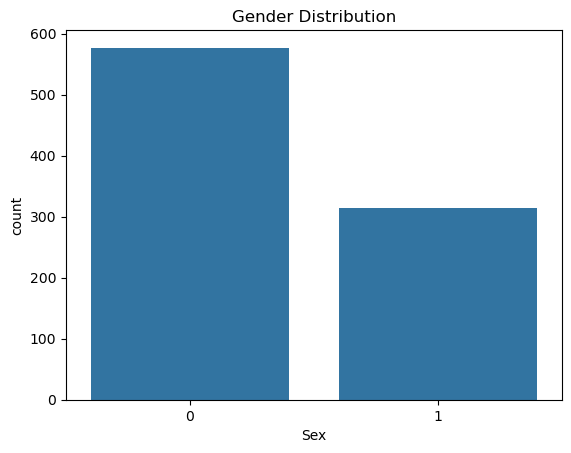

In [247]:
sns.countplot(x="Sex", data=df)

plt.title("Gender Distribution")

plt.show()

Bivariate Analysis

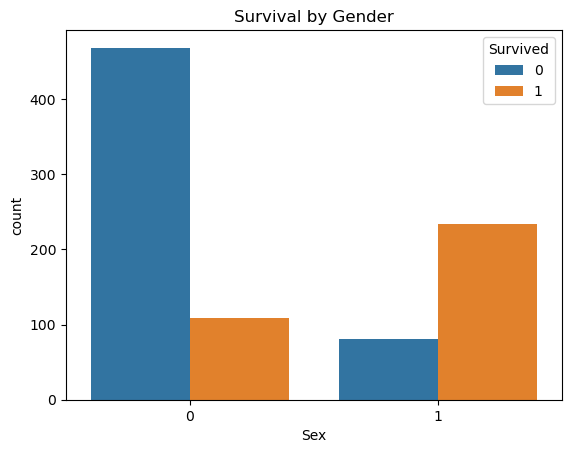

In [248]:
#SURVIVAL BY GENDER. Shows how many males(0) and females(1) survived
sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Survival by Gender")

plt.show()

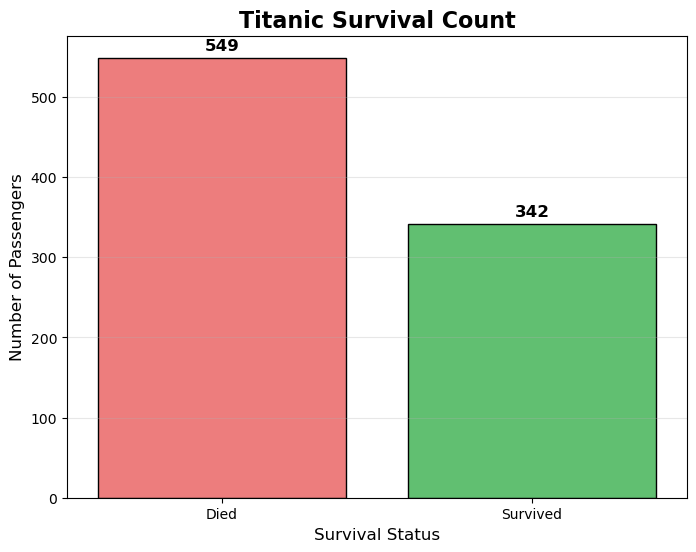

In [249]:
# Full code with all the bells and whistles
import seaborn as sns
import matplotlib.pyplot as plt

# Create the chart
plt.figure(figsize=(8, 6))  # Makes chart bigger
ax = sns.countplot(
    x="Survived", 
    data=df,
    palette=["#ff6b6b", "#51cf66"],  # Red for died, green for survived
    edgecolor="black"  # Black outline around bars
)

# Add title and labels
plt.title("Titanic Survival Count", fontsize=16, fontweight="bold")
plt.xlabel("Survival Status", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)
plt.xticks([0, 1], ["Died", "Survived"])  # Better labels

# Add numbers on top of bars
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 5,
            f'{int(bar.get_height())}', 
            ha='center', 
            va='bottom',
            fontsize=12,
            fontweight="bold")

# Add a grid for easier reading
plt.grid(axis="y", alpha=0.3)

# Display the chart
plt.show()

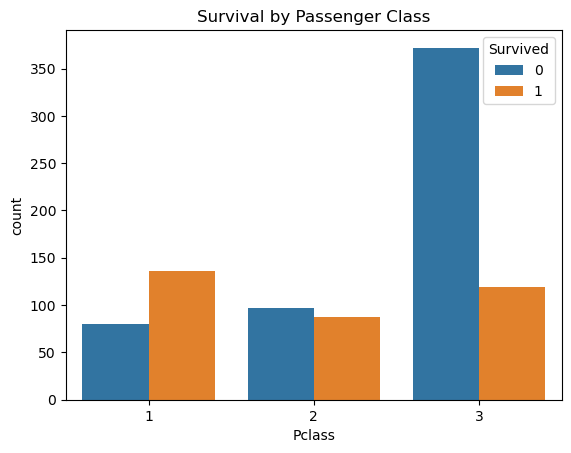

In [250]:
#Survival by Passeger Class
sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Survival by Passenger Class")

plt.show()

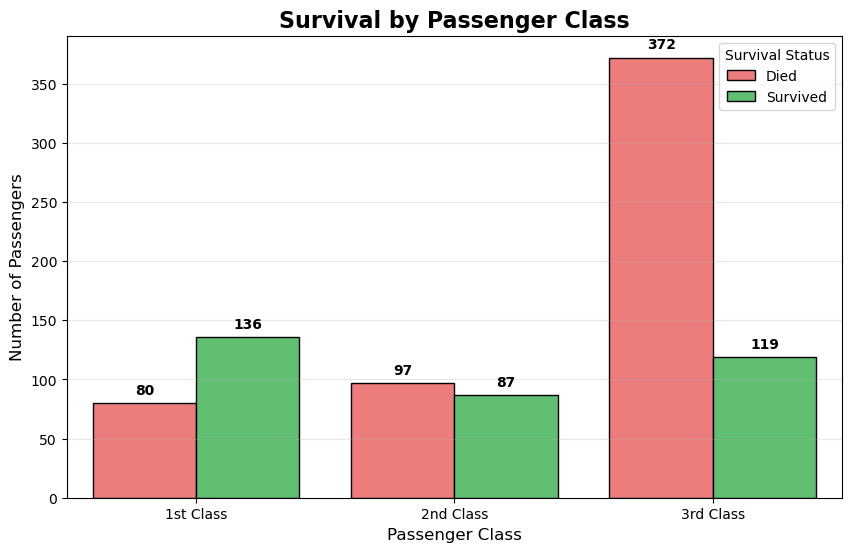

In [251]:
# Create the chart with custom colors
import matplotlib.pyplot as plt
import seaborn as sns

# Make the chart bigger and clearer
plt.figure(figsize=(10, 6))

# Create the countplot with custom colors
ax = sns.countplot(
    x="Pclass", 
    hue="Survived", 
    data=df,
    palette={0: "#ff6b6b", 1: "#51cf66"},  # Red for died, green for survived
    edgecolor="black"  # Black outline around bars
)

# Add title and labels
plt.title("Survival by Passenger Class", fontsize=16, fontweight="bold")
plt.xlabel("Passenger Class", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)

# Change x-axis labels
plt.xticks([0, 1, 2], ["1st Class", "2nd Class", "3rd Class"])

# Change legend labels
plt.legend(title="Survival Status", labels=["Died", "Survived"])

# Add numbers on top of bars
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:  # Only add label if bar has height
        ax.text(
            bar.get_x() + bar.get_width()/2,  # Center of bar
            height + 5,  # Slightly above bar
            f'{int(height)}',  # The number
            ha='center',  # Horizontal alignment
            va='bottom',  # Vertical alignment
            fontsize=10,
            fontweight="bold"
        )

# Add a light grid
plt.grid(axis="y", alpha=0.3)

# Show the chart
plt.show()

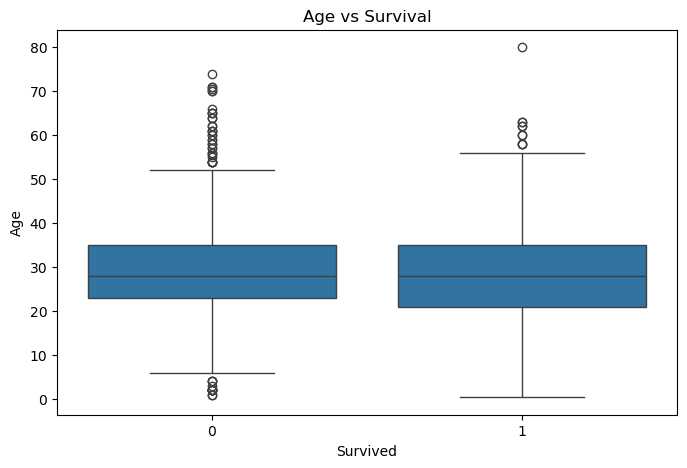

In [252]:
#Age Distribution by Survival
plt.figure(figsize=(8,5))

sns.boxplot(x="Survived", y="Age", data=df)

plt.title("Age vs Survival")

plt.show()

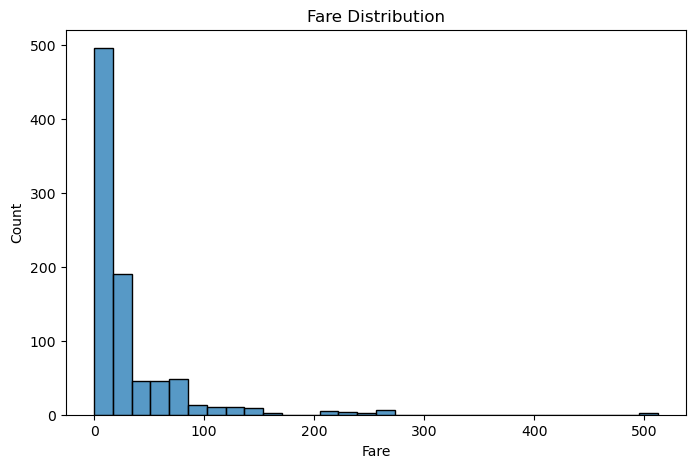

In [253]:
plt.figure(figsize=(8,5))
sns.histplot(df["Fare"], bins=30)

plt.title("Fare Distribution")

plt.show()

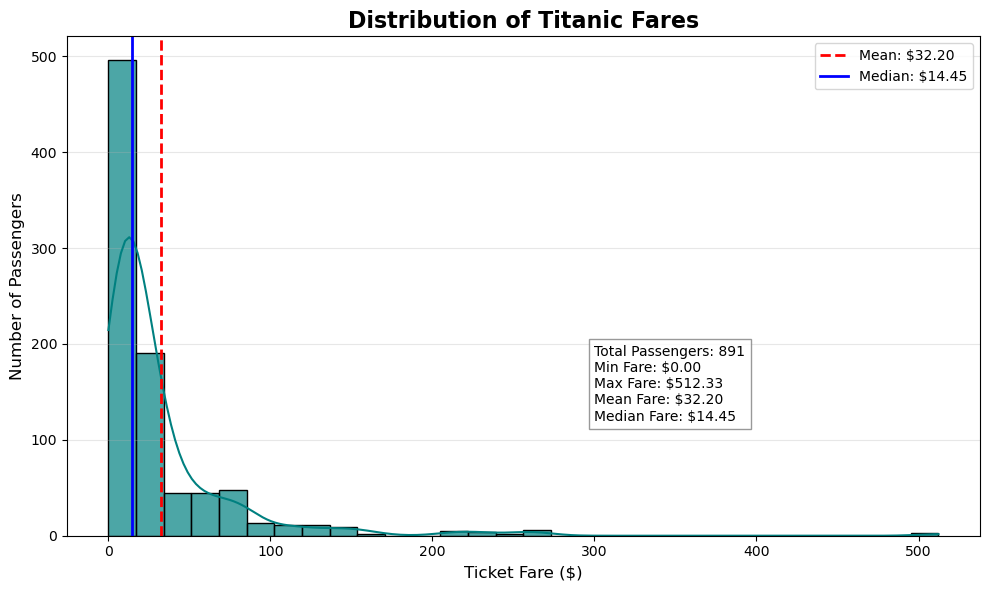


📊 FARE STATISTICS:
Total passengers: 891
Minimum fare: $0.00
Maximum fare: $512.33
Mean fare: $32.20
Median fare: $14.45
Standard deviation: $49.69


In [254]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Create a bigger, clearer chart
plt.figure(figsize=(10, 6))  # Made it even bigger!

# 2. Create the histogram with better settings
ax = sns.histplot(
    df["Fare"], 
    bins=30,                    # Group fares into 30 groups
    kde=True,                   # Add a smooth line showing the shape
    color="teal",               # Make it a nice color
    edgecolor="black",          # Add outlines to bars
    alpha=0.7                   # Make bars slightly transparent
)

# 3. Add mean and median lines
mean_fare = df["Fare"].mean()
median_fare = df["Fare"].median()

# Add vertical lines
ax.axvline(mean_fare, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean_fare:.2f}')
ax.axvline(median_fare, color='blue', linestyle='-', linewidth=2, label=f'Median: ${median_fare:.2f}')

# 4. Add better labels and title
plt.title("Distribution of Titanic Fares", fontsize=16, fontweight="bold")
plt.xlabel("Ticket Fare ($)", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)

# 5. Add a legend
plt.legend()

# 6. Add grid for easier reading
plt.grid(axis="y", alpha=0.3)

# 7. Add statistics box
plt.text(300, 120, f'Total Passengers: {len(df)}\nMin Fare: ${df["Fare"].min():.2f}\nMax Fare: ${df["Fare"].max():.2f}\nMean Fare: ${mean_fare:.2f}\nMedian Fare: ${median_fare:.2f}', 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

# 8. Show the chart
plt.tight_layout()
plt.show()

# 9. Print key statistics
print("\n📊 FARE STATISTICS:")
print(f"Total passengers: {len(df)}")
print(f"Minimum fare: ${df['Fare'].min():.2f}")
print(f"Maximum fare: ${df['Fare'].max():.2f}")
print(f"Mean fare: ${mean_fare:.2f}")
print(f"Median fare: ${median_fare:.2f}")
print(f"Standard deviation: ${df['Fare'].std():.2f}")

CORRELATION: MEASURING THE STRENGTH OG THE RELATION BETWEEN VARIABLES

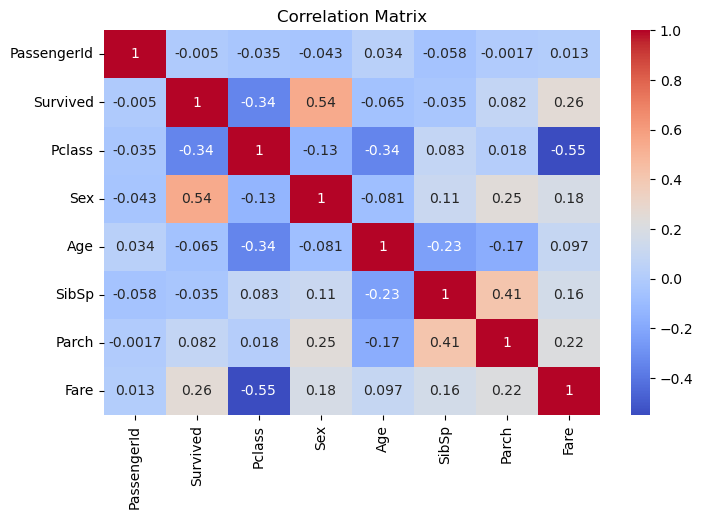

In [255]:
plt.figure(figsize=(8,5))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()


In [256]:
pip install pandasql

Note: you may need to restart the kernel to use updated packages.


In [257]:
import pandas as pd
from pandasql import sqldf

pysqldf = lambda q: sqldf(q, globals())


In [258]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,28.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,C


In [259]:
query = """
SELECT *
FROM df
LIMIT 10;
"""
print(pysqldf(query))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    0  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1  38.0      1      0   
2                             Heikkinen, Miss. Laina    1  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  35.0      1      0   
4                           Allen, Mr. William Henry    0  35.0      0      0   
5                                   Moran, Mr. James    0  28.0      0      0   
6                            McCarth

In [260]:
import sqlite3

In [261]:
df = pd.read_csv("Titanic_clean.csv")

In [262]:
connection = sqlite3.connect("Titanic_database.db")

In [263]:
df.to_sql(
    "titanic",
    connection,
    if_exists = "replace",
    index = False
)

891

In [264]:
query = """
SELECT *
FROM titanic
LIMIT 10;
"""
pd.read_sql_query(
    query,
    connection
)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",0,28.0,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",0,54.0,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",0,2.0,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",1,27.0,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",1,14.0,1,0,237736,30.0708,C


In [265]:
#Count number of passengers
query = """
SELECT COUNT(*) AS  Total_Passengers
FROM titanic;
"""
pd.read_sql_query(
    query,
    connection
)

,Total_Passengers
0,891


In [266]:
#Count number od Suvivors
query = """
SELECT Survived,
COUNT(*) AS Number_of_Passengers
FROM titanic
GROUP BY  Survived;
"""
pd.read_sql_query(
    query,
    connection
)

,Survived,Number_of_Passengers
0,0,549
1,1,342


In [269]:
#Number of male(0) and female(1) passengers

query = """
SELECT Sex,
COUNT(*) AS Total
FROM titanic
GROUP BY Sex;
"""
pd.read_sql_query(
    query,
    connection
)

,Sex,Total
0,0,577
1,1,314


In [271]:
#Average Age
query = """
SELECT AVG(Age) AS Average_Age
FROM titanic;
"""
pd.read_sql_query(
    query,
    connection
)

,Average_Age
0,29.361582


In [272]:
#Average Fare
query = """
SELECT AVG(Fare) AS Average_Fare
FROM titanic;
"""
pd.read_sql_query(
    query,
    connection
)

,Average_Fare
0,32.204208


In [273]:
#Average Fare by Passenger Class
query = """
SELECT 
Pclass,
AVG(Fare) AS Average_Fare
FROM titanic
GROUP BY Pclass;
"""
pd.read_sql_query(
    query,
    connection
)

,Pclass,Average_Fare
0,1,84.154687
1,2,20.662183
2,3,13.675550


In [274]:
#Survival Rate by Passenger Class
query = """
SELECT 
Pclass,
AVG(Survived)*100 AS Survival_Rate
FROM titanic
GROUP BY Pclass;
"""
pd.read_sql_query(
    query,
    connection
)

,Pclass,Survival_Rate
0,1,62.962963
1,2,47.282609
2,3,24.236253


In [276]:
#Survival Rate By Gender
query = """
SELECT
Sex,
AVG(Survived)*100 AS Survival_Rate
FROM titanic
GROUP BY Sex;
"""
pd.read_sql_query(
    query,
    connection
)

,Sex,Survival_Rate
0,0,18.890815
1,1,74.203822


In [280]:
#Top 10 Highest Fare
query = """
SELECT 
Name,
Fare
FROM titanic
ORDER BY Fare DESC
LIMIT 10;
"""
pd.read_sql_query(
    query,
    connection
)

,Name,Fare
0,"Ward, Miss. Anna",512.3292
1,"Cardeza, Mr. Thomas Drake Martinez",512.3292
2,"Lesurer, Mr. Gustave J",512.3292
3,"Fortune, Mr. Charles Alexander",263.0000
4,"Fortune, Miss. Mabel Helen",263.0000
5,"Fortune, Miss. Alice Elizabeth",263.0000
6,"Fortune, Mr. Mark",263.0000
7,"Ryerson, Miss. Emily Borie",262.3750
8,"Ryerson, Miss. Susan Parker ""Suzette""",262.3750
9,"Baxter, Mr. Quigg Edmond",247.5208


In [281]:
#Youngest Passenger
query = """
SELECT *
FROM titanic
ORDER BY Age ASC
LIMIT 1
"""
pd.read_sql_query(
    query,
    connection
)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,804,1,3,"Thomas, Master. Assad Alexander",0,0.42,0,1,2625,8.5167,C


In [282]:
#Oldest Passenger 

query = """
SELECT *
FROM  titanic
ORDER BY Age DESC
LIMIT 1;
"""
pd.read_sql_query(
    query,
    connection
)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",0,80.0,0,0,27042,30.0,S


In [284]:
#Average Age by Gender
query = """
SELECT 
Sex,
AVG(Age) AS Average_Age
FROM titanic
GROUP BY Sex;
"""
pd.read_sql_query(
    query,
    connection
)

,Sex,Average_Age
0,0,30.140676
1,1,27.929936


In [285]:
#Count passenger in Each Embarkment Port
query = """
SELECT 
Embarked,
COUNT(*) AS Total
FROM titanic
GROUP BY Embarked
"""
pd.read_sql_query(
    query,
    connection
)

,Embarked,Total
0,C,168
1,Q,77
2,S,646


In [286]:
# Number of Passengers who survived
query = """
SELECT 
survived,
COUNT(*) AS Total
FROM titanic
GROUP BY Survived;
"""
pd.read_sql_query(
    query,
    connection
)

,Survived,Total
0,0,549
1,1,342


In [291]:
#Percentage of Passengers that survived
query = """
SELECT
    ROUND(AVG(Survived) * 100, 2) AS Survival_Percentage
FROM titanic;
"""

pd.read_sql_query(query, connection)

,Survival_Percentage
0,38.38


In [307]:
#Pclass with highest survival rate
query = """
SELECT 
    Pclass,
    ROUND(AVG(Survived) *100, 2) AS Survival_Rate
FROM titanic
GROUP BY Pclass
ORDER BY Survival_Rate DESC;
"""
pd.read_sql_query(
    query,
    connection
)

,Pclass,Survival_Rate
0,1,62.96
1,2,47.28
2,3,24.24


In [308]:
#Gender with the highest survival rate
query = """
SELECT
    Sex,
    ROUND(AVG(Survived)*100, 2) AS Survival_Rate
FROM titanic
GROUP BY Sex
ORDER BY Survival_Rate DESC;
"""
pd.read_sql_query(
    query,
    connection
)


,Sex,Survival_Rate
0,1,74.20
1,0,18.89


In [313]:
#Average of survivors VS non-Survivors
query = """
SELECT
    Survived,
    ROUND(AVG(Age), 2) AS Survival_Rate
FROM titanic
GROUP BY Survived;
"""
pd.read_sql_query(
    query,
    connection
)

,Survived,Survival_Rate
0,0,30.03
1,1,28.29


In [315]:
#Embarkation Port with the most Passengers
query = """
SELECT 
    Embarked,
    COUNT(*) AS Total_Passengers
FROM titanic
GROUP BY Embarked
ORDER BY Total_Passengers DESC;
"""
pd.read_sql_query(
    query,
    connection
)

,Embarked,Total_Passengers
0,S,646
1,C,168
2,Q,77


In [320]:
#Which Passenger paid the highest fare
query = """
SELECT 
    Name,
    Fare,
    Age,
    Embarked
FROM titanic
ORDER BY Fare DESC
LIMIT 1;
"""
pd.read_sql_query(
    query,
    connection
)

,Name,Fare,Age,Embarked
0,"Ward, Miss. Anna",512.3292,35.0,C


In [321]:
#Find out every information about the passenger who paid the highest
query = """
SELECT *
FROM titanic
ORDER BY Fare DESC
LIMIT 1;
"""
pd.read_sql_query(
    query,
    connection
)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,259,1,1,"Ward, Miss. Anna",1,35.0,0,0,PC 17755,512.3292,C


In [323]:
#Which class paid the highest Fare/
query = """
SELECT 
    Pclass,
    ROUND(AVG(Fare), 2) AS Average_Fare
FROM titanic
GROUP BY Pclass
ORDER BY Average_Fare DESC;
"""
pd.read_sql_query(
    query,
    connection
)

,Pclass,Average_Fare
0,1,84.15
1,2,20.66
2,3,13.68


In [324]:
#Passengers younger than 18 years
query = """
SELECT
    COUNT(*) AS Passenger_Under_18
FROM titanic
WHERE Age < 18
"""
pd.read_sql_query(
    query,
    connection
)

,Passenger_Under_18
0,113


In [325]:
#Average Fare paid by survivors compared to non-survivors
query = """
SELECT
    Survived,
    ROUND(AVG(Fare), 2) AS Average_Fare
FROM titanic
GROUP BY Survived;
"""
pd.read_sql_query(
    query,
    connection
)

,Survived,Average_Fare
0,0,22.12
1,1,48.40


In [326]:
#Number of passengers in each class
query = """
SELECT
    Pclass,
    COUNT(*) AS Total_Passengers
FROM titanic
GROUP BY Pclass;
"""

pd.read_sql_query(query, connection)

,Pclass,Total_Passengers
0,1,216
1,2,184
2,3,491


In [327]:
#average Fare paid per gender
query = """
SELECT
    Sex,
    ROUND(AVG(Fare), 2) AS Average_Fare
FROM titanic
GROUP BY Sex;
"""

pd.read_sql_query(query, connection)

,Sex,Average_Fare
0,0,25.52
1,1,44.48


In [328]:
#Number of survivors by sex
query = """
SELECT
    Sex,
    COUNT(*) AS Total_Survivors
FROM titanic
WHERE Survived = 1
GROUP BY Sex;
"""

pd.read_sql_query(query, connection)

,Sex,Total_Survivors
0,0,109
1,1,233
